## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results DiffGoL Model**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 1$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (15,15)
model_name = 'DiffGoL'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

cols2omit = 1
num_rows = 1
threshold = 0.5

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoL Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

metrics2compute = ['Accuracy', 'Recall', 'Specificity','Precision', 'F1Score']

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)
print(predictions_paths)

{221: PosixPath('../Data/15x15_1_221/Results/DiffGoL/predictions.csv'), 502: PosixPath('../Data/15x15_1_502/Results/DiffGoL/predictions.csv'), 700: PosixPath('../Data/15x15_1_700/Results/DiffGoL/predictions.csv'), 1204: PosixPath('../Data/15x15_1_1204/Results/DiffGoL/predictions.csv'), 3340: PosixPath('../Data/15x15_1_3340/Results/DiffGoL/predictions.csv'), 4501: PosixPath('../Data/15x15_1_4501/Results/DiffGoL/predictions.csv'), 6054: PosixPath('../Data/15x15_1_6054/Results/DiffGoL/predictions.csv'), 6621: PosixPath('../Data/15x15_1_6621/Results/DiffGoL/predictions.csv'), 8421: PosixPath('../Data/15x15_1_8421/Results/DiffGoL/predictions.csv'), 15678: PosixPath('../Data/15x15_1_15678/Results/DiffGoL/predictions.csv'), 19302: PosixPath('../Data/15x15_1_19302/Results/DiffGoL/predictions.csv'), 38475: PosixPath('../Data/15x15_1_38475/Results/DiffGoL/predictions.csv'), 77293: PosixPath('../Data/15x15_1_77293/Results/DiffGoL/predictions.csv'), 91827: PosixPath('../Data/15x15_1_91827/Results/

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.6166 ± 0.0037
val_loss: 0.6274 ± 0.0049


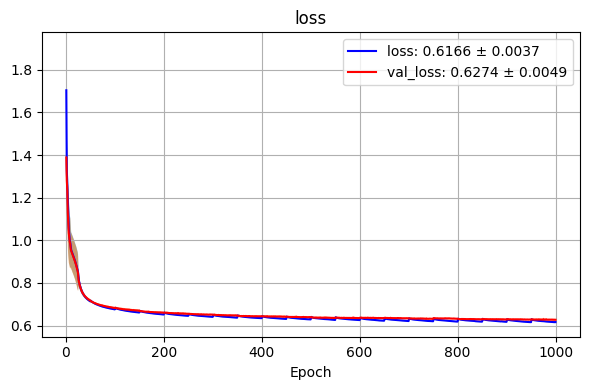

In [4]:
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8526 ± 0.0006
Accuracy_fin: 0.9057 ± 0.0008
Recall_init: 0.6388 ± 0.0022
Recall_fin: 0.5989 ± 0.0037
Specificity_init: 0.9143 ± 0.0005
Specificity_fin: 0.9923 ± 0.0002
Precision_init: 0.6826 ± 0.0011
Precision_fin: 0.9564 ± 0.0012
F1Score_init: 0.6600 ± 0.0015
F1Score_fin: 0.7365 ± 0.0028


--- Results Initial States (15 seeds) ---
Density (true): 22.39% ± 9.39%
Density (pred): 23.84% ± 9.65%
Error/seed:     1.46% ± 0.04%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.37% ± 0.05%
HUC% (0.4, 0.6): 4.86% ± 0.09%
HUC% (0.35, 0.65): 7.60% ± 0.13%
Fuzziness Index: 0.2809 ± 0.1455
MSE (prob):0.1107 ± 0.0650
MSE (bin):0.1474 ± 0.0891
MSE (all-zero): 0.2239 ± 0.0939
Wasserstein (EMD): 1.3402 ± 0.0026


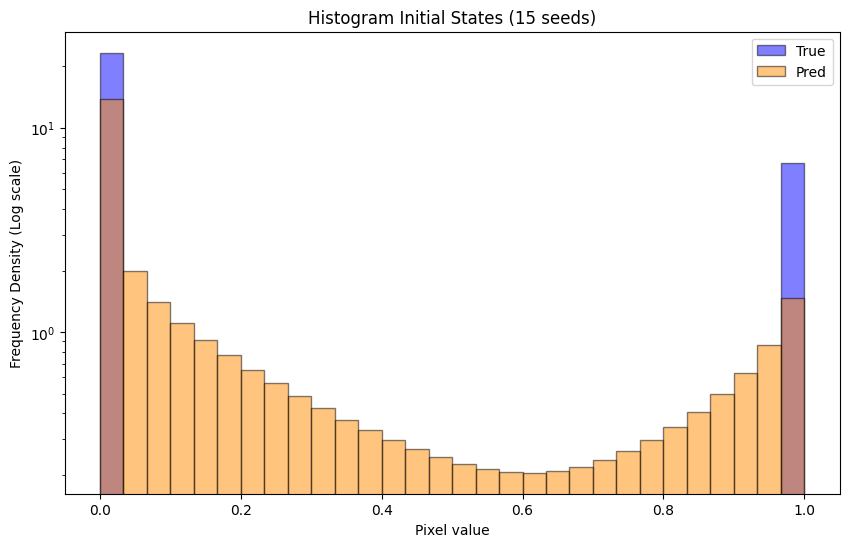

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 22.00% ± 9.81%
Density (pred): 13.39% ± 5.02%
Error/seed:     8.61% ± 0.05%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.54% ± 0.03%
HUC% (0.4, 0.6): 5.10% ± 0.06%
HUC% (0.35, 0.65): 7.68% ± 0.08%
Fuzziness Index: 0.1778 ± 0.0916
MSE (prob):0.0617 ± 0.0401
MSE (bin):0.0943 ± 0.0640
MSE (all-zero): 0.2200 ± 0.0981
Wasserstein (EMD): 1.3814 ± 0.0059


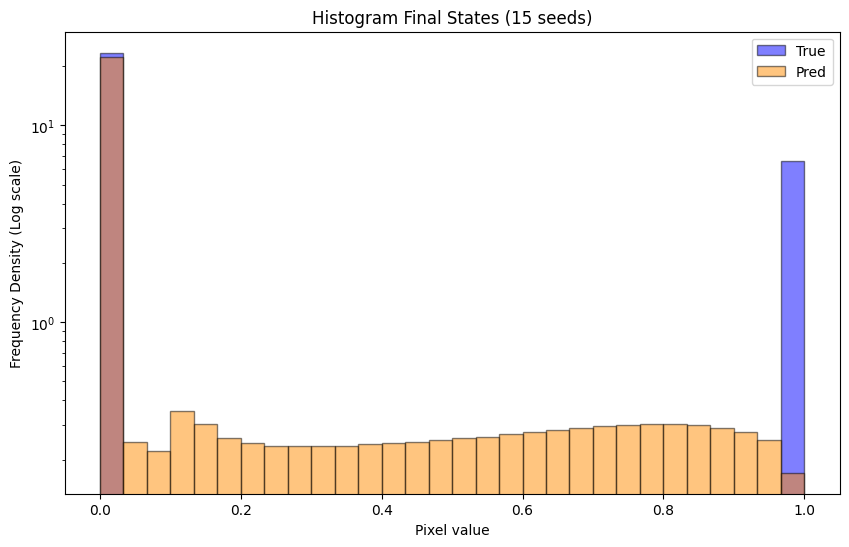

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

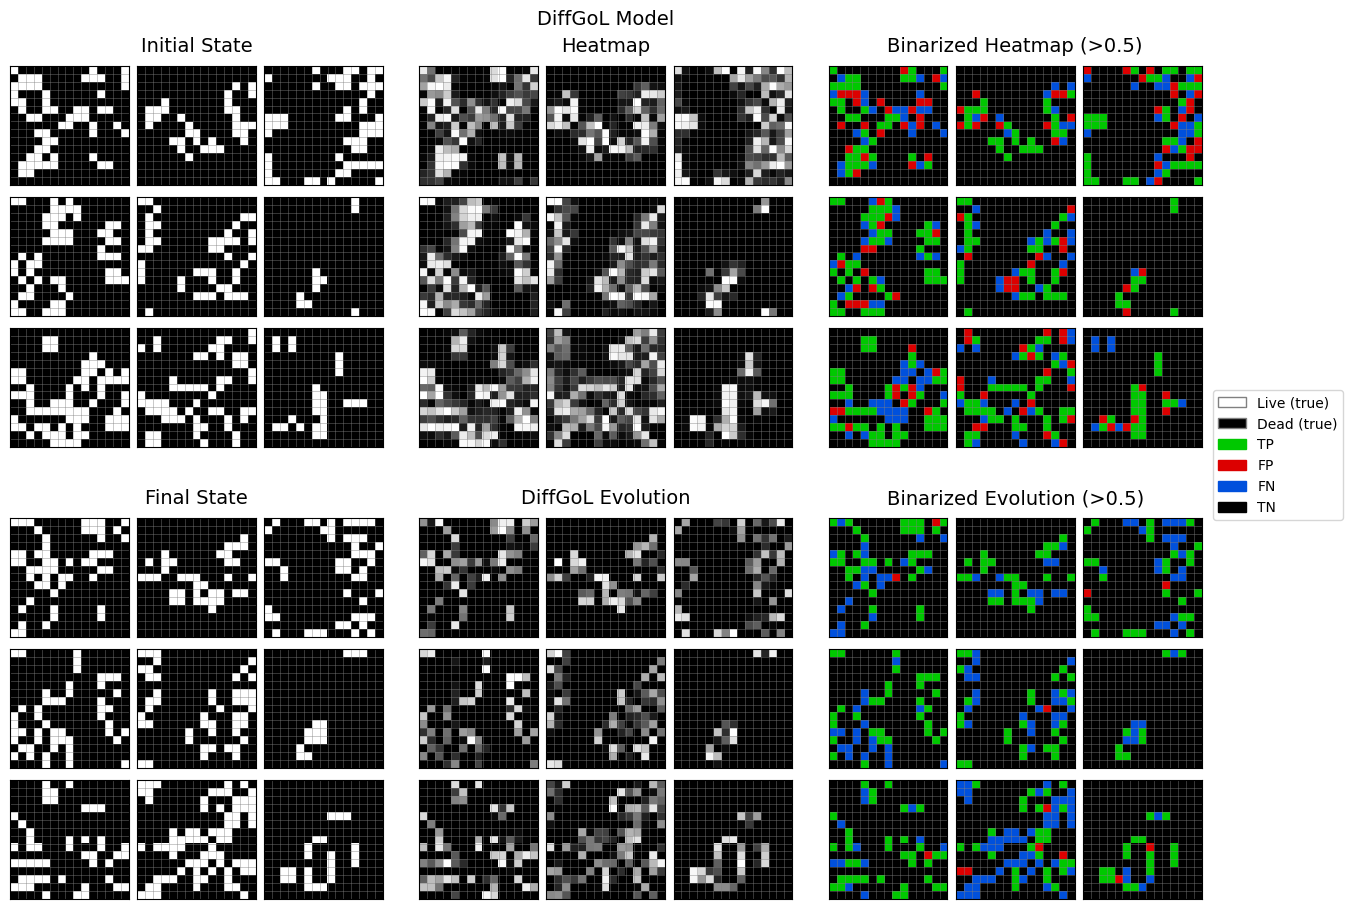

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False) 

### <span style='color:rgb(10,110,217)'><u>**Thresholds**</u></span>

Threshold: 0.2605 ± 0.0016


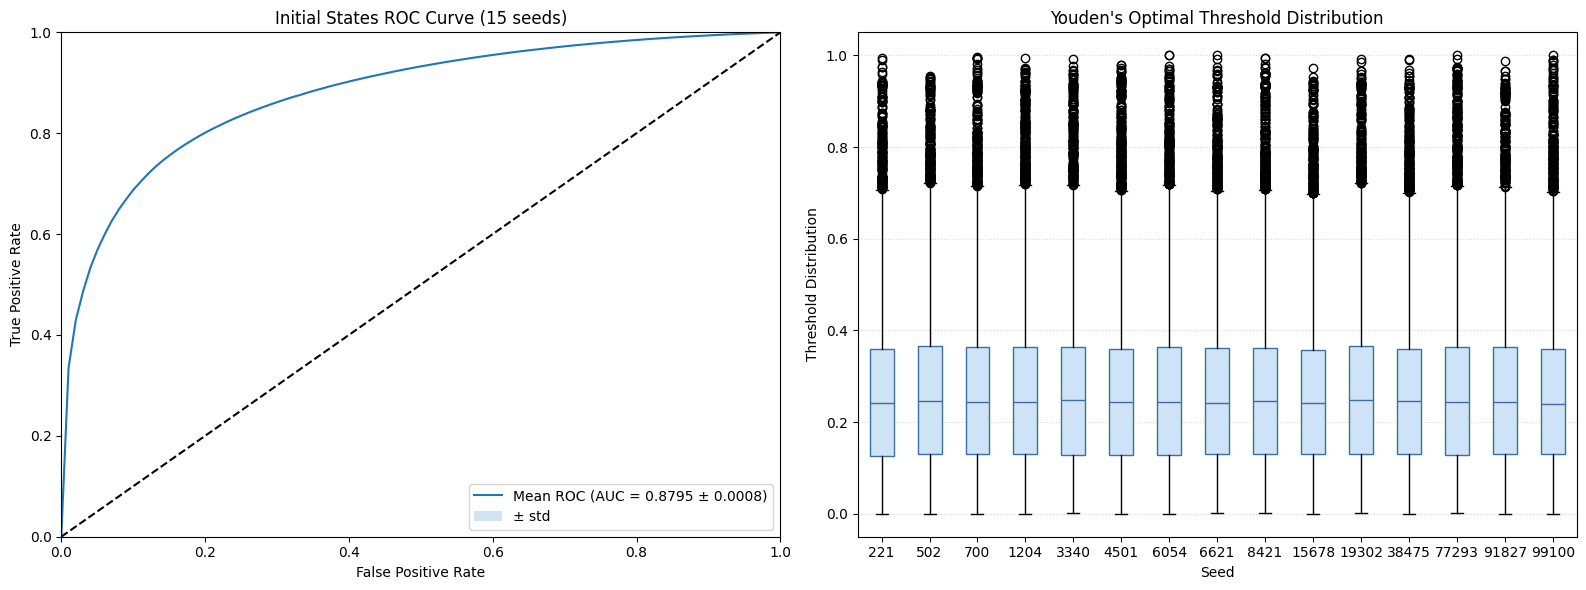

Threshold: 0.1158 ± 0.0020


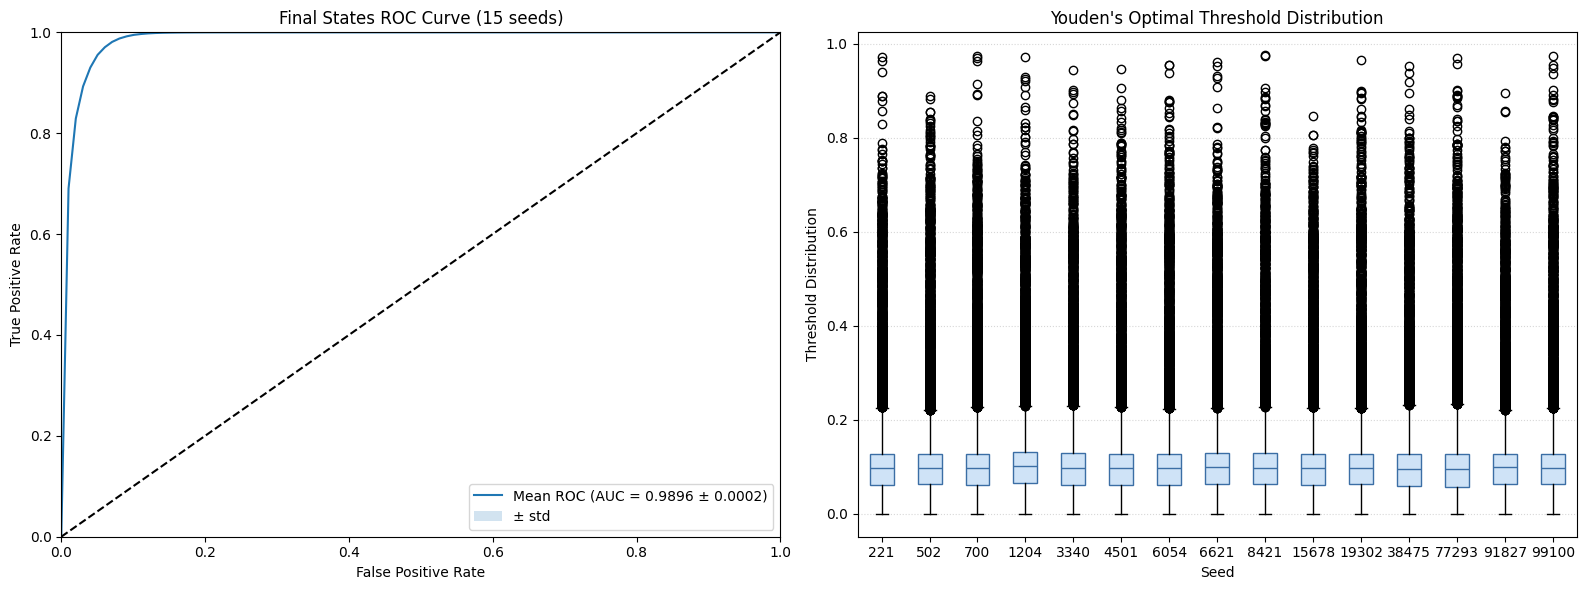

In [9]:
eval_tools.computeROC(predictions_paths, test_data, 'init', shape)
eval_tools.computeROC(predictions_paths, test_data, 'fin', shape)